## Solubility datasets

### Solubility dataset by Cui et al

In [23]:
import pandas as pd

solubility_data1 = pd.read_csv("/home/mabarr/TCruzi_pipeline/solubility_prediction/cui_et_al.csv")
solubility_data1 = solubility_data1.dropna()

duplicates_inchi = solubility_data1.duplicated(subset=["InChIKey"])
print(f"Number of duplicated inchikeys: {duplicates_inchi.sum()}")

duplicates_smiles = solubility_data1.duplicated(subset=["SMILES"])
print(f"Number of duplicated SMILES: {duplicates_smiles.sum()}")

solubility_data_unique = solubility_data1.drop_duplicates(subset=["InChIKey"], keep="first")
solubility_data_unique = solubility_data_unique.drop_duplicates(subset=["SMILES"], keep="first")


print(f"Original rows: {len(solubility_data1)}")
print(f"Rows after removing duplicates: {len(solubility_data_unique)}")



Number of duplicated inchikeys: 2
Number of duplicated SMILES: 0
Original rows: 9943
Rows after removing duplicates: 9941


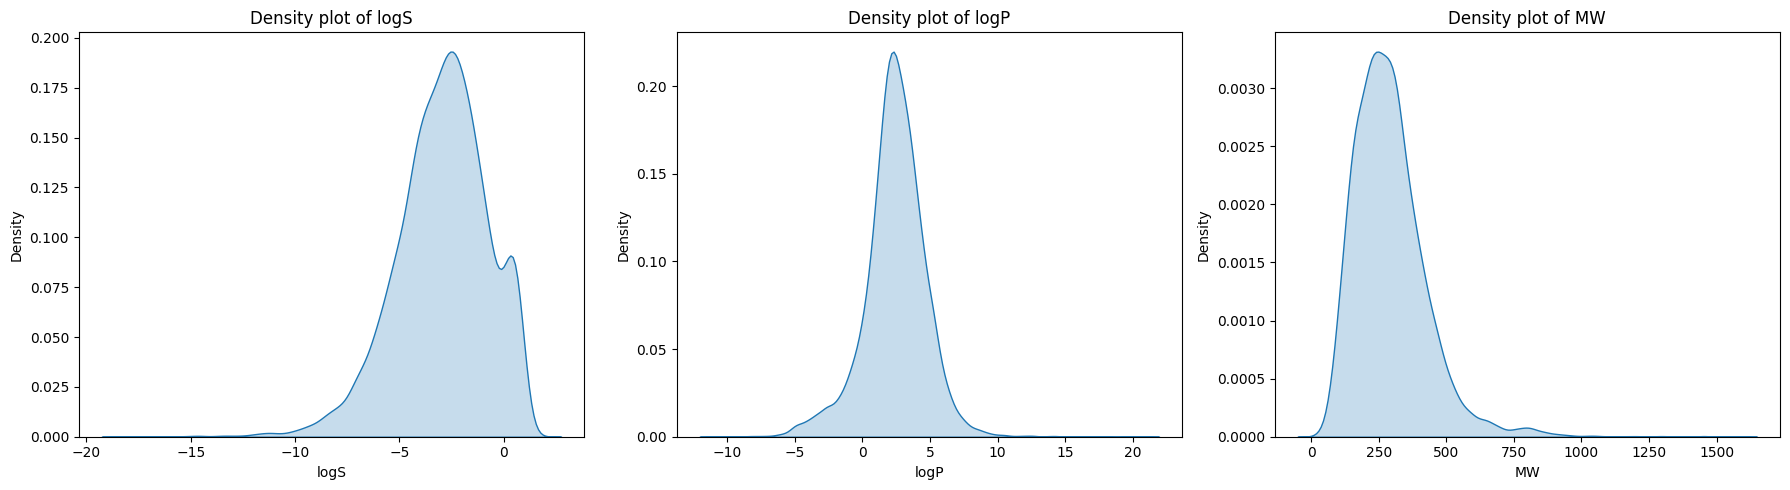

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["logS", "logP", "MW"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

for ax, var in zip(axes, variables):
    sns.kdeplot(data=solubility_data_unique, x=var, fill=True, ax=ax)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.set_title(f"Density plot of {var}")

plt.tight_layout()
plt.show()

### SOMAS solubility dataset

In [36]:
import numpy as np

solubility_data2 = pd.read_csv("/home/mabarr/TCruzi_pipeline/solubility_prediction/somas_gao_et_al.csv")

duplicates_inchi = solubility_data2.duplicated(subset=["Standard InChIKey"])
print(f"Number of duplicated inchikeys: {duplicates_inchi.sum()}")

duplicates_smiles = solubility_data2.duplicated(subset=["SMILES"])
print(f"Number of duplicated SMILES: {duplicates_smiles.sum()}")

solubility_data_unique = solubility_data2.drop_duplicates(subset=["Standard InChIKey"], keep="first")
solubility_data_unique = solubility_data_unique.drop_duplicates(subset=["SMILES"], keep="first")


print(f"Original rows: {len(solubility_data2)}")
print(f"Rows after removing duplicates: {len(solubility_data_unique)}")

solubility_data_unique["logS"] = np.log10(solubility_data_unique["Experimental Solubility in Water"])

Number of duplicated inchikeys: 0
Number of duplicated SMILES: 0
Original rows: 11692
Rows after removing duplicates: 11692


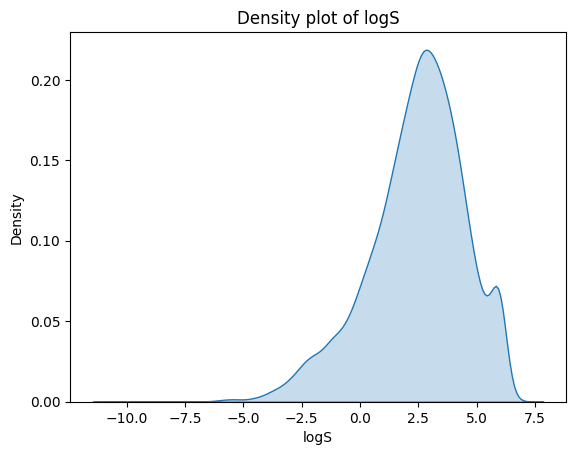

In [37]:


sns.kdeplot(data=solubility_data_unique, x="logS", fill=True)
plt.xlabel("logS")
plt.ylabel("Density")
plt.title("Density plot of logS")
plt.show()

In [33]:
solubility_data_unique.columns

Index(['Name', 'SMILES', 'Molar Mass', 'CAS Number',
       'Experimental Solubility in Water', 'Temperature',
       'Experiment Reference', 'Datagroup', 'Solvation Energy',
       'Dipole Moment', 'Molecular Volume', 'Molecular Surface Area', 'QXX',
       'QYY', 'QZZ', 'HOMO', 'LUMO', 'gap', 'Standard InChIKey', 'Cal logP',
       'Cal MR', 'TPSA', 'Labute ASA', 'Balaban J index', 'Bertz CT index',
       'Isomer'],
      dtype='object')